In [43]:
from typing import Tuple
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [49]:
def add_speed_columns(df):
    # Вычисляем разницу во времени (в секундах)
    dt = df['timestamp'].diff()

    # Расчет угловой скорости: (угол_текущий - угол_предыдущий) / (время_текущее - время_предыдущее)
    df['pan_speed'] = df['pan_angle'].diff() / dt
    df['tilt_speed'] = df['tilt_angle'].diff() / dt

    # Первая строка будет NaN (так как нет предыдущей для расчета дифференциала)
    # Можно заполнить нулем или оставить как есть
    df[['pan_speed', 'tilt_speed']] = df[['pan_speed', 'tilt_speed']].fillna(0)
    return df

def read_data_frames(experiment_dir, acoustic_file_name, opu_file_name) -> Tuple[pd.DataFrame, pd.DataFrame]:
    column_names = ['timestamp', 'pan_angle', 'tilt_angle']
    acoustic_df = pd.read_csv(f'{experiment_dir}/{acoustic_file_name}', names=column_names, sep=';')
    opu_df = pd.read_csv(f'{experiment_dir}/{opu_file_name}', names=column_names, sep=';')

    acoustic_df[['timestamp']] /= 1000
    acoustic_df['pan_angle'] *= 180 / np.pi
    acoustic_df['tilt_angle'] *= 180 / np.pi

    opu_df[['timestamp']] /= 1000
    opu_df['pan_angle'] *= 180 / np.pi
    opu_df['tilt_angle'] *= 180 / np.pi

    acoustic_min_ts = acoustic_df['timestamp'].min()
    opu_min_ts = opu_df['timestamp'].min()

    # TODO костыль из-за некорректных данных
    acoustic_df['timestamp'] += opu_min_ts - acoustic_min_ts

    acoustic_max_ts = acoustic_df['timestamp'].max()
    opu_max_ts = opu_df['timestamp'].max()

    ts_start = np.max([acoustic_min_ts, opu_min_ts])
    ts_end = np.min([acoustic_max_ts, opu_max_ts])

    acoustic_df = acoustic_df[(acoustic_df['timestamp'] >= ts_start) & (acoustic_df['timestamp'] <= ts_end)]
    opu_df = opu_df[(opu_df['timestamp'] >= ts_start) & (opu_df['timestamp'] <= ts_end)]

    acoustic_df = add_speed_columns(acoustic_df)
    opu_df = add_speed_columns(opu_df)

    return acoustic_df, opu_df

In [50]:
experiment_dir = 'data/2026_04_10_acoustic_logs/dynamic_hor_swing_0-40_pan_speed_10'

acoustic_file_name = 'log_acoustic_2026_04_09_17_38_00.csv'
opu_file_name = 'log_opu_2026_04_09_17_38_00.csv'

acoustic_df, opu_df = read_data_frames(experiment_dir, acoustic_file_name, opu_file_name)

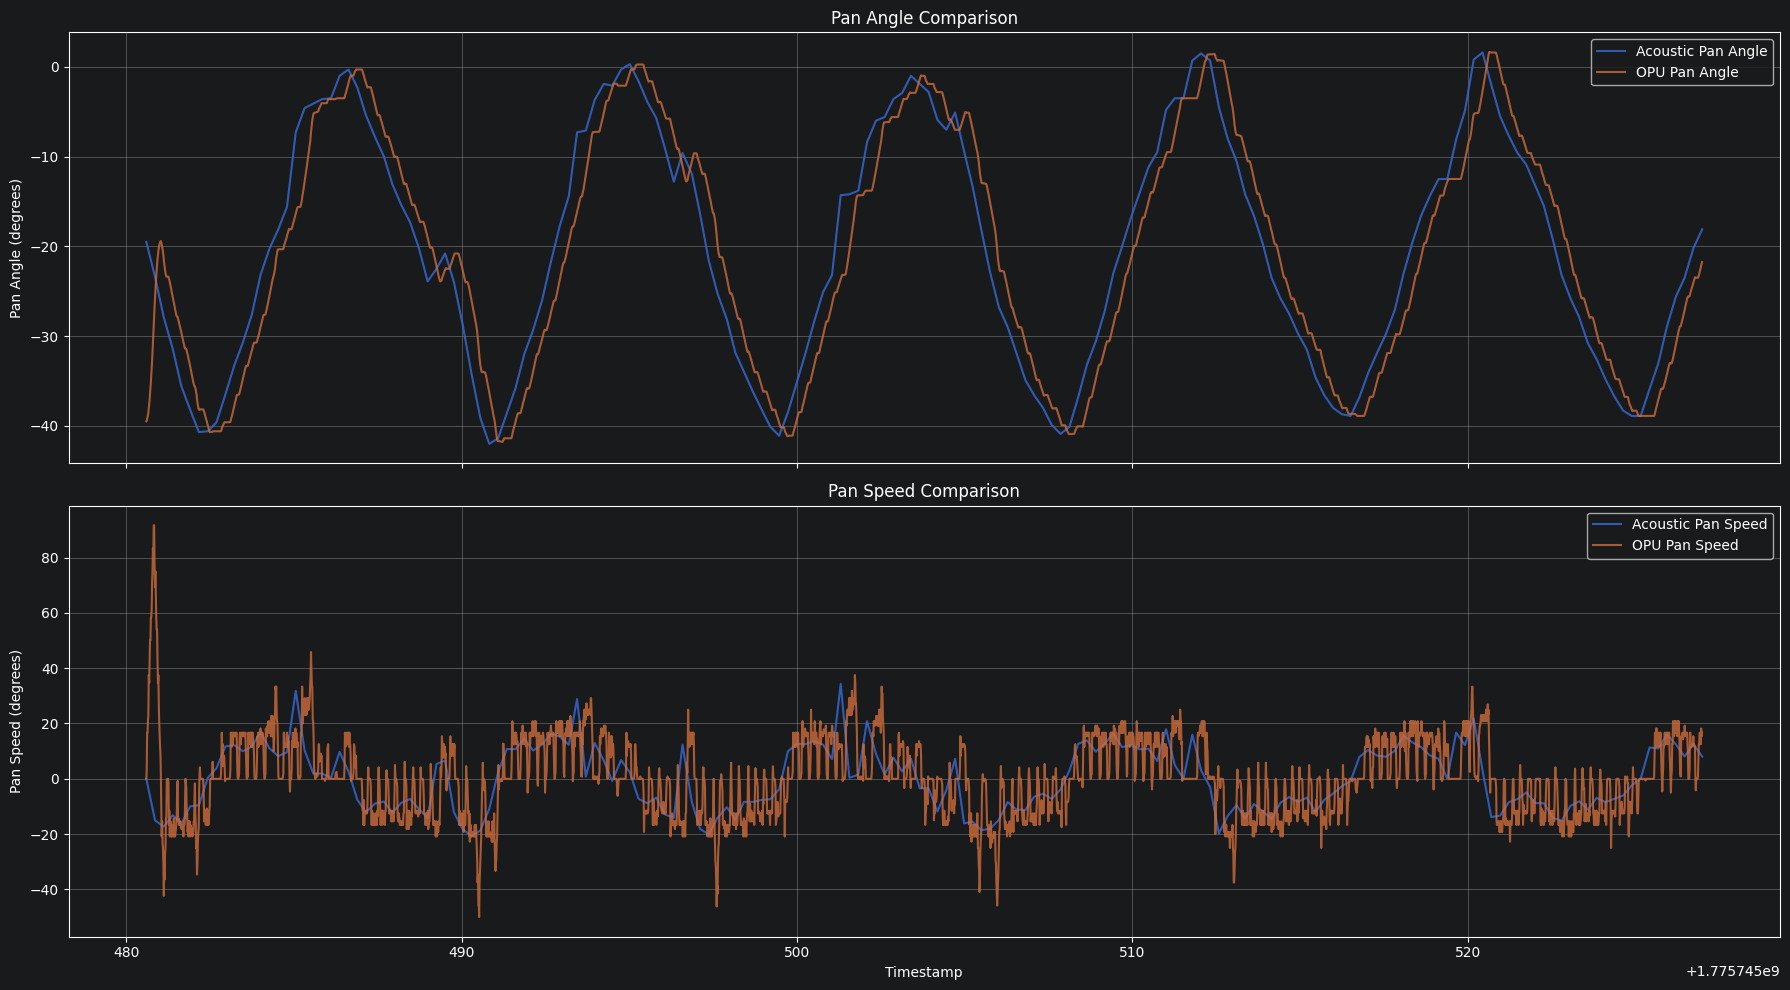

In [51]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# 1. График для Pan Angle
ax1.plot(acoustic_df['timestamp'], acoustic_df['pan_angle'], label='Acoustic Pan Angle', alpha=0.8)
ax1.plot(opu_df['timestamp'], opu_df['pan_angle'], label='OPU Pan Angle', alpha=0.8)
ax1.set_ylabel('Pan Angle (degrees)')
ax1.set_title('Pan Angle Comparison')
ax1.legend()
ax1.grid(True)

# 2. График для Pan Speed
ax2.plot(acoustic_df['timestamp'], acoustic_df['pan_speed'], label='Acoustic Pan Speed', alpha=0.8)
ax2.plot(opu_df['timestamp'], opu_df['pan_speed'], label='OPU Pan Speed', alpha=0.8)
ax2.set_xlabel('Timestamp')
ax2.set_ylabel('Pan Speed (degrees)')
ax2.set_title('Pan Speed Comparison')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

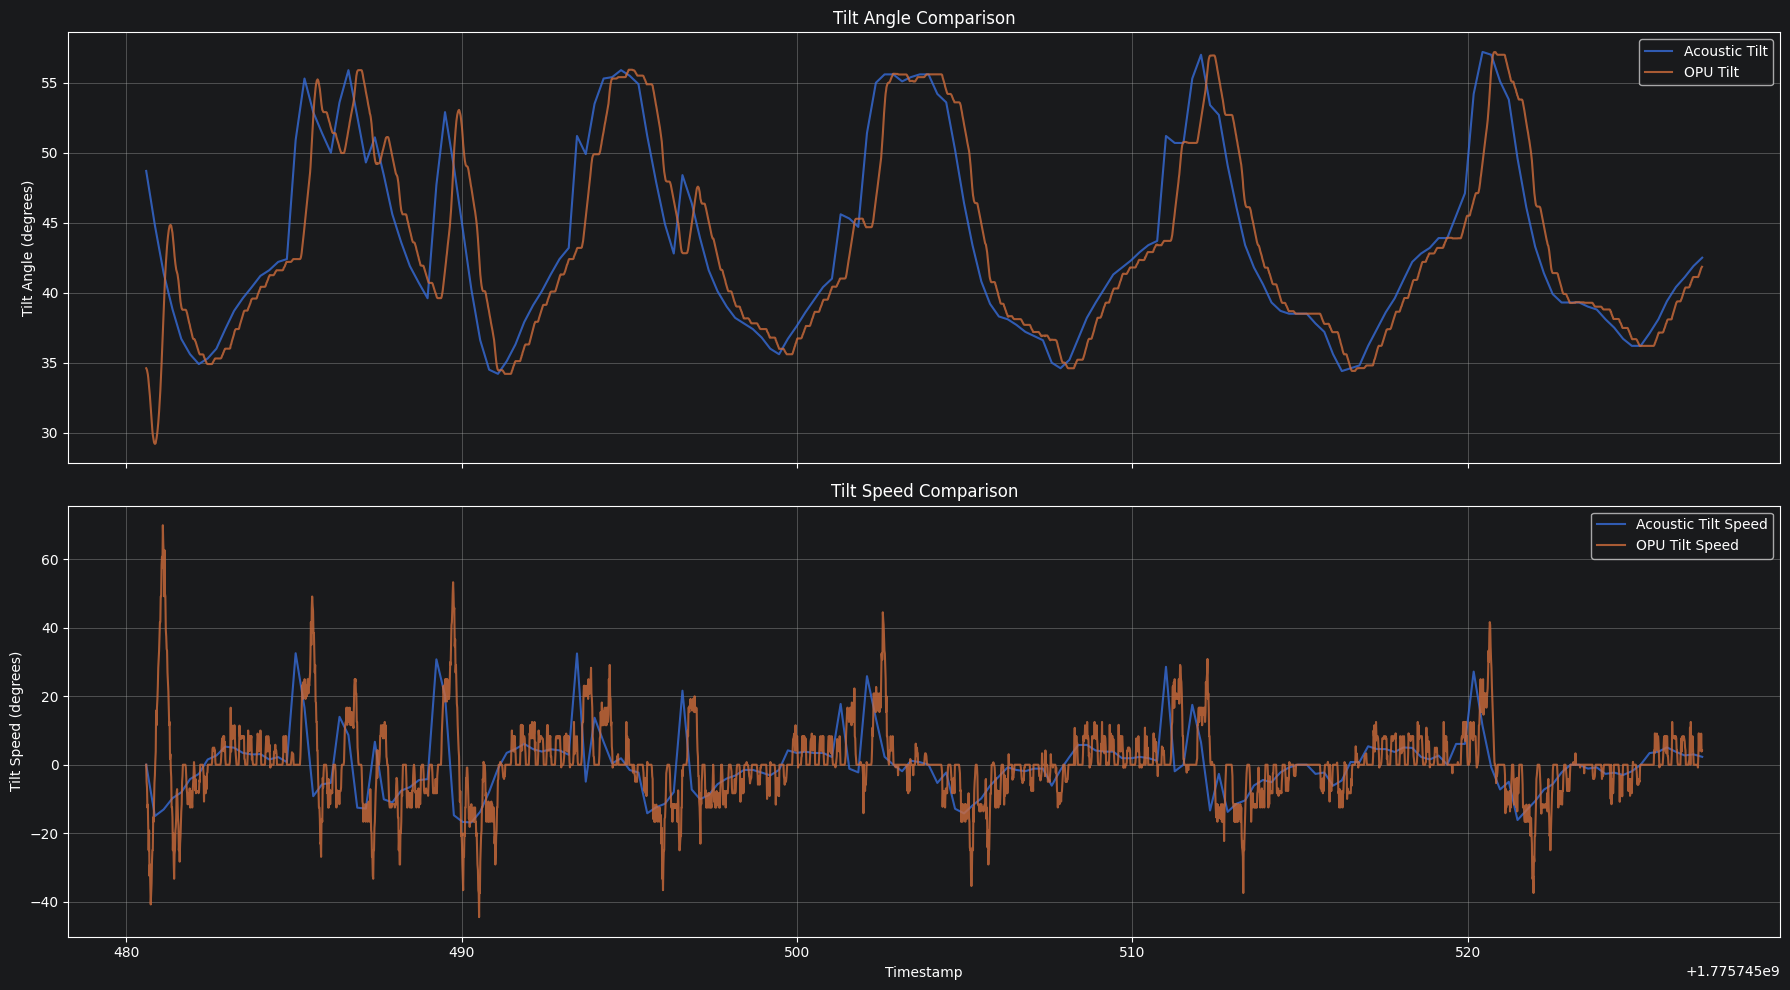

In [53]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

# 1. График для Pan Angle
ax1.plot(acoustic_df['timestamp'], acoustic_df['tilt_angle'], label='Acoustic Tilt', alpha=0.8)
ax1.plot(opu_df['timestamp'], opu_df['tilt_angle'], label='OPU Tilt', alpha=0.8)
ax1.set_ylabel('Tilt Angle (degrees)')
ax1.set_title('Tilt Angle Comparison')
ax1.legend()
ax1.grid(True)

# 2. График для Tilt Speed
ax2.plot(acoustic_df['timestamp'], acoustic_df['tilt_speed'], label='Acoustic Tilt Speed', alpha=0.8)
ax2.plot(opu_df['timestamp'], opu_df['tilt_speed'], label='OPU Tilt Speed', alpha=0.8)
ax2.set_xlabel('Timestamp')
ax2.set_ylabel('Tilt Speed (degrees)')
ax2.set_title('Tilt Speed Comparison')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()